In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from pyfonts import load_google_font

# Map

In [2]:
# Load shape file
georgia = gpd.read_file("shapefiles/DuBoisChallenge - Georgia Counties w 1870 & 1880 data.shp")

In [3]:
# Check projection
georgia.crs

<Projected CRS: ESRI:102003>
Name: USA_Contiguous_Albers_Equal_Area_Conic
Axis Info [cartesian]:
- [east]: Easting (metre)
- [north]: Northing (metre)
Area of Use:
- undefined
Coordinate Operation:
- name: unnamed
- method: Albers Equal Area
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [4]:
# Reproject to WGS 84
georgia = georgia.to_crs("EPSG:4326")

In [5]:
# Select relevant columns
georgia = georgia[["NHGISNAM", "ICPSRNAM", "geometry"]]

In [6]:
georgia.shape

(137, 3)

# Acre

In [7]:
# Load data
ga1899 = pd.read_csv("ga1899.csv")

In [8]:
ga1899.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142 entries, 0 to 141
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   County1890              137 non-null    object 
 1   County1890up            137 non-null    object 
 2   Black population 1890   137 non-null    float64
 3   Acres 1899              137 non-null    float64
 4   color                   137 non-null    object 
 5   mostly black            137 non-null    float64
 6   FIPS code               135 non-null    float64
 7   population 2010         135 non-null    float64
 8   Area sq mi              137 non-null    float64
 9   Acres 1899/Area sq mi   137 non-null    object 
 10  Census Population 1890  137 non-null    float64
 11  City                    5 non-null      object 
 12  lat                     5 non-null      object 
 13  lon                     5 non-null      object 
dtypes: float64(7), object(7)
memory usage: 15.

In [9]:
# Select relevant columns
acre1899 = ga1899[["County1890", "County1890up", "Acres 1899", "color"]]

In [10]:
# Drop missing values
acre1899 = acre1899.dropna()

In [11]:
acre1899.shape

(137, 4)

# Merge georgia and acre1899

In [12]:
# Merge gdf and df
gdf = pd.merge(georgia, acre1899, left_on="ICPSRNAM", right_on="County1890up", how="left")

In [13]:
gdf.shape

(137, 7)

# Cities

In [14]:
# Create new df with selecting relevant columns and dropping missing values
city_df = ga1899[["City", "lat", "lon"]].dropna().reset_index(drop=True)

In [15]:
city_df

,City,lat,lon
0,Atlanta,33°45′ N,84°23′ W
1,Columbus,32°30′ N,84°56′ W
2,Macon,32°50′ N,83°39′ W
3,Savannah,32°01′ N,81°07′ W
4,Augusta,33°28′ N,81°58′ W


In [16]:
# Add county and country to get accurate geocoding results
city_df["City"] = city_df["City"] + ", Georgia, US"

In [17]:
# Geocode cities
city_locations = gpd.tools.geocode(city_df.City)

In [18]:
# Check projection
city_locations.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [19]:
city_locations

,geometry,address
0,POINT (-84.38982 33.75447),"Atlanta, Georgia, United States"
1,POINT (-84.98804 32.46107),"Columbus, Georgia, United States"
2,POINT (-83.6324 32.84069),"Macon, Georgia, United States"
3,POINT (-81.09213 32.07901),"Savannah, Georgia, United States"
4,POINT (-81.97484 33.47097),"Augusta, Georgia, United States"


In [20]:
# Function to split addrress
def split_address(address):
    return pd.Series(address.split(",", 1))

# Apply split addrress function to the "City" column 
city_locations[["City", "Address"]] = city_locations["address"].apply(split_address)

# Drop "Address" column
city_locations.drop(columns=["Address"], inplace=True)

In [21]:
cities = city_locations.copy()

# Colors

In [22]:
# Color dictionary
color_dict = {
    "yellow": "#ebb500",
    "pink": "#e19291",
    "red": "#ba0d32",
    "blue": "#53659e",
    "green": "#2e4534",    
    "lightgray": "#d3c7b1",
    "brown": "#9f8263",     
}

# Apply color mapping
gdf["color_new"] = gdf["color"].map(color_dict)

# Custom font

In [23]:
# Custom font
font_bold = load_google_font("Public Sans", weight="bold")
font_light = load_google_font("Public Sans", weight="thin")

# Plot

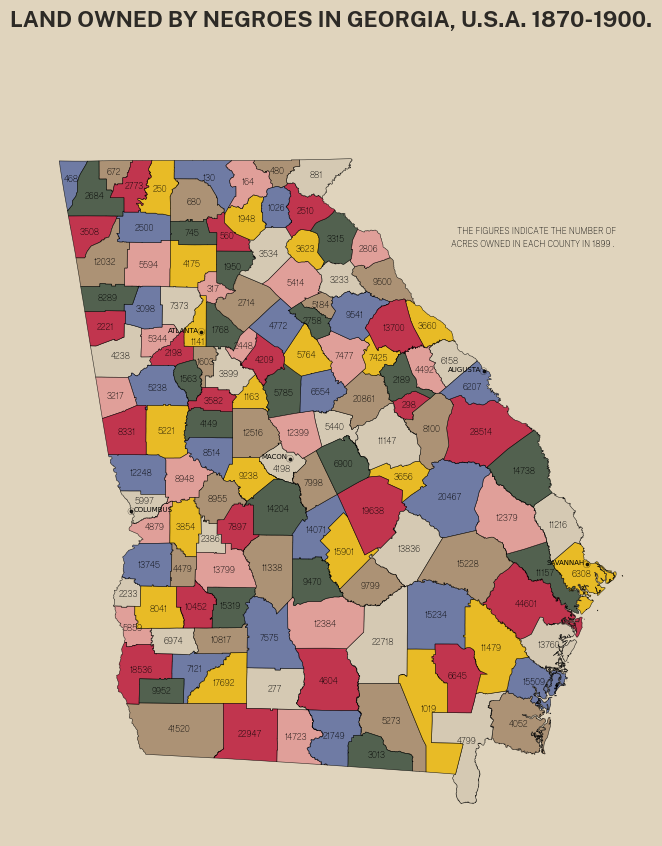

In [24]:
# Create figure
fig, ax = plt.subplots(figsize=(8, 10), facecolor="#e0d4bd")  

# Plot Georgia
gdf.plot(
    ax=ax,
    color=gdf["color_new"],
    alpha=0.8,
    ec="black",
    lw=0.4
)

# Iterate over rows to annotate counties
for i, row in gdf.iterrows():    
    centroid = row.geometry.centroid     
    county_value = row["County1890"].strip()      

    # Offset based on county
    if county_value =="Fulton":  # Atlanta
        offset = -0.1
    elif county_value == "Muscogee":  # Columbus
        offset = 0.025
    elif county_value == "Bibb":  # Macon
        offset = -0.04
    else:
        offset = 0  
    ax.text(centroid.x, centroid.y+offset, f'{row["Acres 1899"]:.0f}', font=font_light, ha="center", va="center", fontsize=6)

# Iterate over rows to plot cities
for i, row in cities.iterrows():    
    centroid = row.geometry.centroid

    ax.scatter(centroid.x, centroid.y, color="none", ec="black", alpha=0.8, s=25, lw=0.2)
    ax.scatter(centroid.x, centroid.y, color="black", alpha=0.8, s=3)

    if i in [1]:
        ax.text(centroid.x+0.02, centroid.y, f'{row["City"].upper()}', size=5, ha="left")
    else:
        ax.text(centroid.x-0.02, centroid.y, f'{row["City"].upper()}', size=5, ha="right")

# Remove axis
ax.axis("off")

# Annotation
fig.text(0.65, 0.73, "   THE FIGURES INDICATE THE NUMBER OF\nACRES OWNED IN EACH COUNTY IN 1899 .", size=6, font=font_light, linespacing=1.5)

# Title
fig.text(0.5, 0.95, "LAND OWNED BY NEGROES IN GEORGIA, U.S.A. 1870-1900.", alpha=0.8, size=16, font=font_bold, ha="center")

plt.show()

#plt.savefig("plate20.jpg")

In [25]:
import matplotlib.image as mpimg
from PIL import Image
import numpy as np

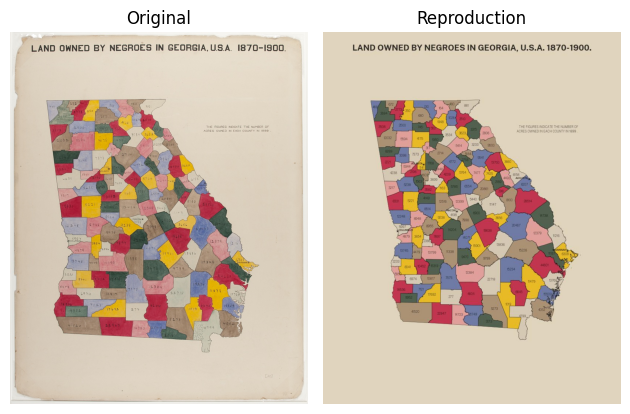

In [26]:
# Load images 
image1 = Image.open("original-plate-20.jpg")
image2 = Image.open("plate20.jpg")

# Convert to numpy arrays
images = [np.array(image1), np.array(image2)]
titles = ["Original", "Reproduction"]

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2)

# Loop through axes, images, and titles
for ax, img, title in zip(axes, images, titles):
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(title)

# Adjust the layout and show
plt.tight_layout()
plt.show()

# Save the combined figure 
#plt.savefig("plate20sidebyside.png", dpi=300)